# IPL Data Analysis & Visualization (2008–2025)

In [ ]:
# import Library

import numpy as np
import pandas as pd
import seaborn as sns

In [ ]:
# Load dataset

ipl=pd.read_csv('/content/ipl.csv')

In [ ]:
ipl.sample(5)

,team1,team2,match_date,toss_winner,toss_decision,winner,player_of_match,venue,city,team1_players,team2_players,season,match_number,match_type,result,result_margin,target_runs,target_overs,super_over
1059,Kolkata Knight Riders,Royal Challengers Bengaluru,2024-04-21,Royal Challengers Bengaluru,field,Kolkata Knight Riders,AD Russell,"Eden Gardens, Kolkata",Kolkata,"Suyash Sharma, PD Salt, SP Narine, A Raghuvans...","Yash Dayal, V Kohli, F du Plessis, WG Jacks, R...",17,36,League,runs,1.0,223.0,20.0,N
491,Rajasthan Royals,Delhi Daredevils,2015-05-03,Delhi Daredevils,field,Rajasthan Royals,AM Rahane,Brabourne Stadium,Mumbai,"AM Rahane, SR Watson, KK Nair, JP Faulkner, SP...","MA Agarwal, SS Iyer, JP Duminy, Yuvraj Singh, ...",8,34,League,runs,23.0,173.0,20.0,N
74,Royal Challengers Bangalore,Kolkata Knight Riders,2009-04-29,Kolkata Knight Riders,bat,Royal Challengers Bangalore,MV Boucher,Kingsmead,Durban,"JH Kallis, SP Goswami, KP Pietersen, V Kohli, ...","BB McCullum, CH Gayle, BJ Hodge, SC Ganguly, M...",2,17,League,wickets,5.0,140.0,20.0,N
802,Sunrisers Hyderabad,Delhi Capitals,2020-10-27,Delhi Capitals,field,Sunrisers Hyderabad,WP Saha,Dubai International Cricket Stadium,NaN,"DA Warner, WP Saha, MK Pandey, KS Williamson, ...","AM Rahane, S Dhawan, MP Stoinis, SO Hetmyer, R...",13,47,League,runs,88.0,220.0,20.0,N
651,Kings XI Punjab,Sunrisers Hyderabad,2018-04-19,Kings XI Punjab,bat,Kings XI Punjab,CH Gayle,Punjab Cricket Association IS Bindra Stadium,Chandigarh,"KL Rahul, CH Gayle, MA Agarwal, KK Nair, AJ Fi...","WP Saha, S Dhawan, KS Williamson, YK Pathan, M...",11,16,League,runs,15.0,194.0,20.0,N


In [ ]:
ipl.isnull().sum()

,0
team1,0
team2,0
match_date,0
toss_winner,0
toss_decision,0
winner,23
player_of_match,0
venue,0
city,51
team1_players,0


# Q1. How many matches were played in each season?

In [ ]:

ipl['season'].value_counts().sort_index()

,count
season,
1,58
2,57
3,60
4,73
5,74
6,76
7,60
8,59
9,60


In [ ]:
# graph  -> we used figure level functions
sns.catplot(x=ipl['season'],kind='count')

# Q2.  Which season had the highest number of matches?

In [ ]:
hs=ipl['season'].value_counts().sort_index(ascending=False)
hs.head(1)


,count
season,
18,74


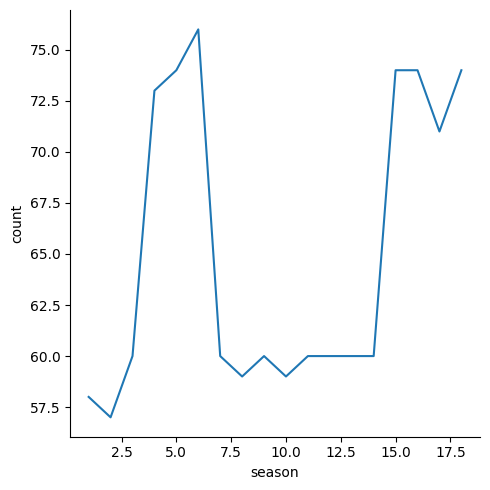

In [ ]:
# Graph
df=pd.DataFrame(hs)
df=df.reset_index()
df.columns=['season','count']
df

sns.relplot(df,x='season',y='count',kind='line')



# Q3. Which venues hosted the most IPL matches?

In [ ]:
v=ipl['venue'].value_counts().head(1)

,count
venue,
Eden Gardens,77


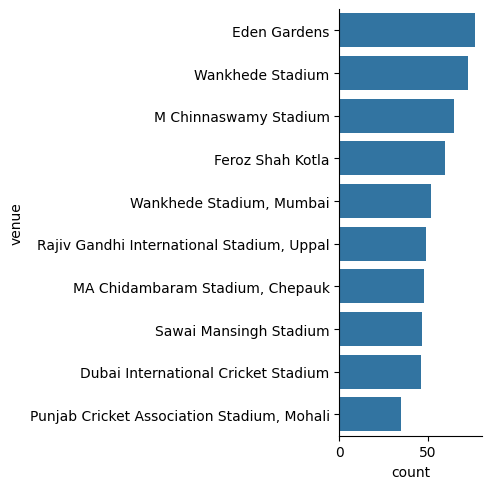

In [ ]:
import matplotlib.pyplot as plt

sns.catplot(y=ipl['venue'],kind='count', order=ipl['venue'].value_counts().head(10).index)


# Q4. Which team has won the most matches in IPL history?

In [ ]:
ipl['winner'].value_counts().head(1)

,count
winner,
Mumbai Indians,151


# Q5. What is the win percentage of every team?

In [ ]:
ipl.head(2)

,team1,team2,match_date,toss_winner,toss_decision,winner,player_of_match,venue,city,team1_players,team2_players,season,match_number,match_type,result,result_margin,target_runs,target_overs,super_over
0,Royal Challengers Bangalore,Kolkata Knight Riders,2008-04-18,Royal Challengers Bangalore,field,Kolkata Knight Riders,BB McCullum,M Chinnaswamy Stadium,Bangalore,"R Dravid, W Jaffer, V Kohli, JH Kallis, CL Whi...","SC Ganguly, BB McCullum, RT Ponting, DJ Hussey...",1,1,League,runs,140.0,223.0,20.0,N
1,Kings XI Punjab,Chennai Super Kings,2008-04-19,Chennai Super Kings,bat,Chennai Super Kings,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Chandigarh,"K Goel, JR Hopes, KC Sangakkara, Yuvraj Singh,...","PA Patel, ML Hayden, MEK Hussey, MS Dhoni, SK ...",1,2,League,runs,33.0,241.0,20.0,N


In [ ]:
matches_played = (ipl['team1'].value_counts() +
                  ipl['team2'].value_counts())

matches_won = ipl['winner'].value_counts()

win_per = pd.DataFrame({
    'matches_played': matches_played,
    'matches_won': matches_won
})


win_per = win_per.fillna(0)

print(win_per.head(2))


win_per['win_percentage'] = (
    win_per['matches_won'] /
    win_per['matches_played']
) * 100

win_per.sort_values('win_percentage',ascending=False)






                     matches_played  matches_won
Chennai Super Kings             252          142
Deccan Chargers                  75           29


,matches_played,matches_won,win_percentage
Rising Pune Supergiant,16,10,62.500000
Gujarat Titans,60,37,61.666667
Royal Challengers Bengaluru,30,18,60.000000
Chennai Super Kings,252,142,56.349206
Mumbai Indians,277,151,54.512635
Lucknow Super Giants,58,30,51.724138
Kolkata Knight Riders,264,135,51.136364
Rajasthan Royals,235,114,48.510638
Delhi Capitals,106,51,48.113208
Royal Challengers Bangalore,240,114,47.500000


# Q6. Which teams perform best while chasing?

In [ ]:
ipl.head(2)

,team1,team2,match_date,toss_winner,toss_decision,winner,player_of_match,venue,city,team1_players,team2_players,season,match_number,match_type,result,result_margin,target_runs,target_overs,super_over
0,Royal Challengers Bangalore,Kolkata Knight Riders,2008-04-18,Royal Challengers Bangalore,field,Kolkata Knight Riders,BB McCullum,M Chinnaswamy Stadium,Bangalore,"R Dravid, W Jaffer, V Kohli, JH Kallis, CL Whi...","SC Ganguly, BB McCullum, RT Ponting, DJ Hussey...",1,1,League,runs,140.0,223.0,20.0,N
1,Kings XI Punjab,Chennai Super Kings,2008-04-19,Chennai Super Kings,bat,Chennai Super Kings,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Chandigarh,"K Goel, JR Hopes, KC Sangakkara, Yuvraj Singh,...","PA Patel, ML Hayden, MEK Hussey, MS Dhoni, SK ...",1,2,League,runs,33.0,241.0,20.0,N


In [ ]:
chase=ipl[ipl['toss_decision']=='field']['winner'].value_counts()
chase=chase.reset_index()
chase.head(1)
chasedf=pd.DataFrame(chase)
chasedf

,winner,count
0,Mumbai Indians,98
1,Kolkata Knight Riders,84
2,Chennai Super Kings,77
3,Royal Challengers Bangalore,77
4,Rajasthan Royals,72
5,Sunrisers Hyderabad,62
6,Kings XI Punjab,62
7,Delhi Daredevils,38
8,Delhi Capitals,37
9,Gujarat Titans,28


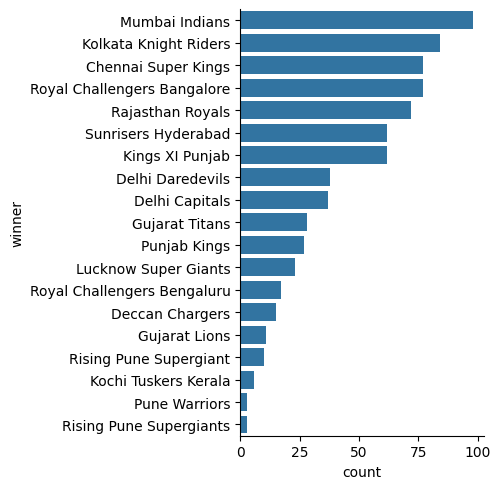

In [ ]:
sns.catplot(x=chasedf['count'],y=chasedf['winner'],kind='bar')

# Q7. Which teams defend targets most successfully?

In [ ]:
ipl.head(2)

,team1,team2,match_date,toss_winner,toss_decision,winner,player_of_match,venue,city,team1_players,team2_players,season,match_number,match_type,result,result_margin,target_runs,target_overs,super_over
0,Royal Challengers Bangalore,Kolkata Knight Riders,2008-04-18,Royal Challengers Bangalore,field,Kolkata Knight Riders,BB McCullum,M Chinnaswamy Stadium,Bangalore,"R Dravid, W Jaffer, V Kohli, JH Kallis, CL Whi...","SC Ganguly, BB McCullum, RT Ponting, DJ Hussey...",1,1,League,runs,140.0,223.0,20.0,N
1,Kings XI Punjab,Chennai Super Kings,2008-04-19,Chennai Super Kings,bat,Chennai Super Kings,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Chandigarh,"K Goel, JR Hopes, KC Sangakkara, Yuvraj Singh,...","PA Patel, ML Hayden, MEK Hussey, MS Dhoni, SK ...",1,2,League,runs,33.0,241.0,20.0,N


In [ ]:
defend=ipl[ipl['toss_decision']=='bat']['winner'].value_counts()
defend=defend.reset_index()
ddf=pd.DataFrame(defend)
ddf
ddf.sort_values('count',ascending=False)



,winner,count
0,Chennai Super Kings,65
1,Mumbai Indians,53
2,Kolkata Knight Riders,51
3,Rajasthan Royals,42
4,Royal Challengers Bangalore,37
5,Sunrisers Hyderabad,31
6,Delhi Daredevils,29
7,Kings XI Punjab,23
8,Deccan Chargers,14
9,Delhi Capitals,14


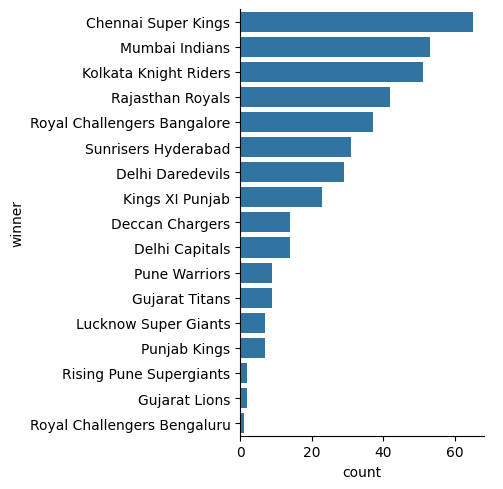

In [ ]:
sns.catplot(y=ddf['winner'],x=ddf['count'],kind='bar')

# Q9. Does winning the toss increase chances of winning?

In [ ]:
ipl.head(2)

,team1,team2,match_date,toss_winner,toss_decision,winner,player_of_match,venue,city,team1_players,team2_players,season,match_number,match_type,result,result_margin,target_runs,target_overs,super_over
0,Royal Challengers Bangalore,Kolkata Knight Riders,2008-04-18,Royal Challengers Bangalore,field,Kolkata Knight Riders,BB McCullum,M Chinnaswamy Stadium,Bangalore,"R Dravid, W Jaffer, V Kohli, JH Kallis, CL Whi...","SC Ganguly, BB McCullum, RT Ponting, DJ Hussey...",1,1,League,runs,140.0,223.0,20.0,N
1,Kings XI Punjab,Chennai Super Kings,2008-04-19,Chennai Super Kings,bat,Chennai Super Kings,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Chandigarh,"K Goel, JR Hopes, KC Sangakkara, Yuvraj Singh,...","PA Patel, ML Hayden, MEK Hussey, MS Dhoni, SK ...",1,2,League,runs,33.0,241.0,20.0,N


In [ ]:
ipl['toss_w']=ipl['toss_winner']==ipl['winner']
toss_win=ipl['toss_w'].value_counts(normalize=True)
toss_win_per = toss_win * 100
toss_win_per

,proportion
toss_w,
True,50.556031
False,49.443969


# Q10. Toss decision trend over the years (Bat vs Field)?

In [ ]:
trend = pd.crosstab(
    ipl['season'],
    ipl['toss_decision']
)
trend

toss_decision,bat,field
season,,
1,26,32
2,35,22
3,39,21
4,25,48
5,37,37
6,45,31
7,19,41
8,25,34
9,11,49


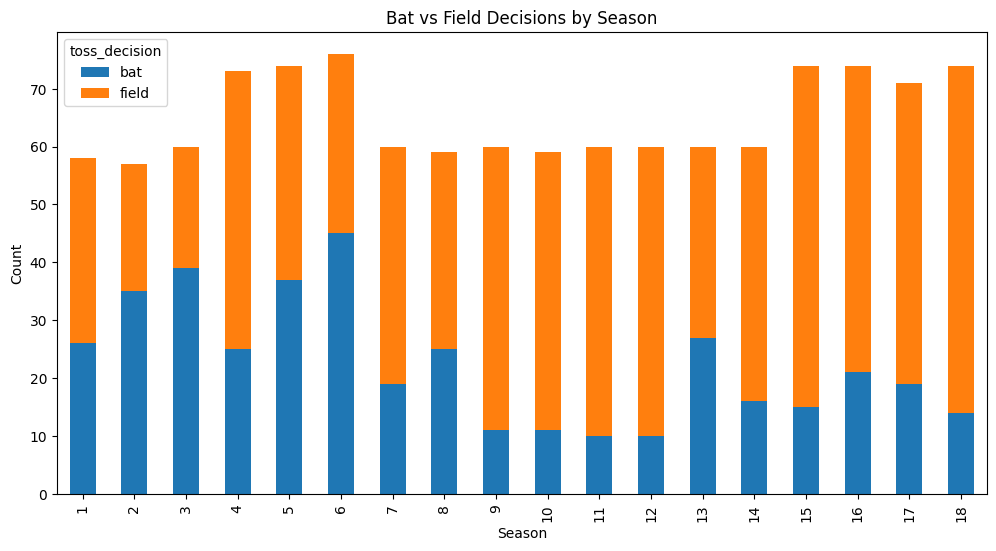

In [ ]:
trend.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title('Bat vs Field Decisions by Season')
plt.xlabel('Season')
plt.ylabel('Count')
plt.show()